# 🎬 Predykcja oceny recenzji filmowej - NLP
### Projekt: Wstęp do Sztucznej Inteligencji

**Cel:** Model przyjmujący tekst recenzji filmowej i zwracający ocenę w skali **1–10**.

**Dataset:** Stanford Large Movie Review Dataset (IMDB) - 50 000 recenzji  
z ocenami numerycznymi zakodowanymi w nazwach plików (`id_ocena.txt`).

**Dwa modele:**
| Model | Opis | Czas (CPU) |
|---|---|---|
| **Baseline** | TF-IDF + Ridge Regression | ~1 min |
| **DistilBERT** | Ekstrakcja cech + głowica regresji | ~20–40 min |


## 1. Instalacja bibliotek

In [92]:
# cuda (optional)
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130

%pip install transformers torch scikit-learn pandas numpy matplotlib seaborn tqdm requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importy i konfiguracja

In [93]:
import os, re, tarfile, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel
from tqdm import tqdm
import requests

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie: {device}")
print(f"PyTorch: {torch.__version__}")


Urządzenie: cuda
PyTorch: 2.12.0+cu130


## 3. Pobieranie i parsowanie danych

### O datasecie
Stanford Large Movie Review Dataset (Maas et al., 2011) zawiera 50 000 recenzji IMDB.  
Co ważne dla nas - **ocena numeryczna jest zakodowana w nazwie pliku**:

```
aclImdb/train/pos/1234_8.txt   →  rating = 8/10
aclImdb/train/neg/5678_2.txt   →  rating = 2/10
```

Oceny 5 i 6 zostały pominięte przez autorów datasetu (uznali je za zbyt neutralne).


In [94]:
DATA_DIR  = Path("data")
IMDB_DIR  = DATA_DIR / "aclImdb"
TAR_PATH  = DATA_DIR / "aclImdb_v1.tar.gz"
DATA_URL  = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

DATA_DIR.mkdir(exist_ok=True)

def download_with_progress(url: str, dest: Path):
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()
    total_mb = int(response.headers.get("content-length", 0)) / 1e6
    downloaded = 0
    with open(dest, "wb") as f:
        for chunk in response.iter_content(chunk_size=65536):
            f.write(chunk)
            downloaded += len(chunk) / 1e6
            print(f"\r  Pobrano: {downloaded:.1f} / {total_mb:.1f} MB", end="", flush=True)
    print()

if not IMDB_DIR.exists():
    if not TAR_PATH.exists():
        print("Pobieranie datasetu (~84.1 MB)...")
        download_with_progress(DATA_URL, TAR_PATH)
    print("Rozpakowywanie...")
    with tarfile.open(TAR_PATH) as tar:
        tar.extractall(DATA_DIR)
    print("Dataset gotowy!")
else:
    print("Dataset już istnieje.")


Dataset już istnieje.


In [95]:
def load_split(split: str) -> pd.DataFrame:
    """Wczytuje recenzje z oceną numeryczną z danego podziału (train/test)."""
    rows = []
    for sentiment in ("pos", "neg"):
        folder = IMDB_DIR / split / sentiment
        for fpath in folder.glob("*.txt"):
            # Format nazwy pliku: {review_id}_{rating}.txt
            rating = int(fpath.stem.split("_")[1])
            text   = fpath.read_text(encoding="utf-8")
            rows.append({"text": text, "rating": rating, "sentiment": sentiment})
    return pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Wczytywanie danych...")
df_all   = load_split("train")
df_test  = load_split("test")

# Podział train/test: 90% trening / 10% walidacja
df_train, df_val = train_test_split(
    df_all, test_size=0.1, random_state=SEED, stratify=df_all["rating"]
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"Trening:    {len(df_train):>6} recenzji")
print(f"Walidacja:  {len(df_val):>6} recenzji")
print(f"Test:       {len(df_test):>6} recenzji")
print(f"\nMożliwe oceny: {sorted(df_train['rating'].unique())}")


Wczytywanie danych...
Trening:     22500 recenzji
Walidacja:    2500 recenzji
Test:        25000 recenzji

Możliwe oceny: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## 4. Eksploracja danych (EDA)

In [ ]:
def clean_text(text: str) -> str:
    """Usuwa tagi HTML i normalizuje białe znaki."""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_train["text"] = df_train["text"].apply(clean_text)
df_val["text"]   = df_val["text"].apply(clean_text)
df_test["text"]  = df_test["text"].apply(clean_text)

df_train["n_chars"] = df_train["text"].str.len()
df_train["n_words"] = df_train["text"].str.split().str.len()

print(df_train[["rating", "n_chars", "n_words"]].describe().round(1))


        rating  n_chars  n_words
count  22500.0  22500.0  22500.0
mean       5.5   1305.8    232.1
std        3.5    991.6    173.0
min        1.0     52.0     10.0
25%        2.0    693.0    126.0
50%        5.5    965.0    173.0
75%        9.0   1588.0    282.0
max       10.0  13593.0   2459.0


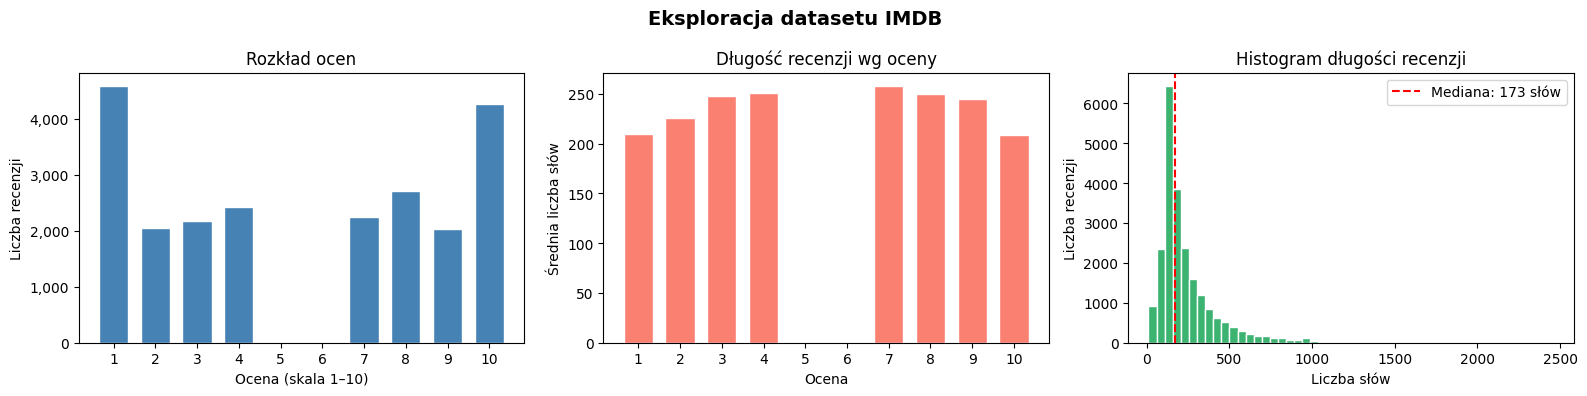

Wykres zapisany jako eda_plots.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Eksploracja datasetu IMDB", fontsize=14, fontweight="bold")

# 1) Rozkład ocen
counts = df_train["rating"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="steelblue", edgecolor="white", width=0.7)
axes[0].set_xlabel("Ocena (skala 1–10)")
axes[0].set_ylabel("Liczba recenzji")
axes[0].set_title("Rozkład ocen")
axes[0].set_xticks(range(1, 11))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 2) Długość recenzji (słowa) wg oceny
avg_words = df_train.groupby("rating")["n_words"].mean()
axes[1].bar(avg_words.index, avg_words.values, color="salmon", edgecolor="white", width=0.7)
axes[1].set_xlabel("Ocena")
axes[1].set_ylabel("Średnia liczba słów")
axes[1].set_title("Długość recenzji wg oceny")
axes[1].set_xticks(range(1, 11))

# 3) Histogram długości recenzji
axes[2].hist(df_train["n_words"], bins=50, color="mediumseagreen", edgecolor="white")
axes[2].set_xlabel("Liczba słów")
axes[2].set_ylabel("Liczba recenzji")
axes[2].set_title("Histogram długości recenzji")
axes[2].axvline(df_train["n_words"].median(), color="red", linestyle="--",
                label=f"Mediana: {int(df_train['n_words'].median())} słów")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany jako eda_plots.png")


In [ ]:
# Przykładowe recenzje dla skrajnych ocen
for rating, label in [(1, "Najgorsza"), (10, "Najlepsza")]:
    sample = df_train[df_train["rating"] == rating].iloc[0]["text"]
    print(f"{'='*65}")
    print(f"{label} ocena ({rating}/10):")
    print(sample[:350] + ("..." if len(sample) > 350 else ""))
    print()


Najgorsza ocena (1/10):
This was thought to be the flagship work of the open source community, something that would stand up and scream at the worlds media to take notice as we're not stuck in the marketing trap with our options in producing fine work with open source tools. After the basic version download ( die hard fan here on a dial-up modem ) eventually got here I hi...

Najlepsza ocena (10/10):
I very much enjoyed "The Revolution Will Not Be Televised". It gave me, once again, a positive feeling about the power of people to decide for themselves how they wish to be governed. It is unfortunate that in Venezuela the twenty percent of wealthy citizens have made all of the decisions for the eighty percent of the poor for decades, if not centu...



## 5. Model bazowy (Baseline): TF-IDF + Ridge Regression

Zanim przejdziemy do głębokiego uczenia, budujemy prosty model klasyczny:

1. **TF-IDF** (Term Frequency–Inverse Document Frequency) - zamienia tekst  
   na wektor liczb, gdzie każdy wymiar odpowiada jednemu słowu (lub bigramowi).  
   Słowa rzadkie i charakterystyczne mają wyższe wagi.
2. **Ridge Regression** - liniowa regresja z regularyzacją L2, odporna na overfitting.

Wynik tego modelu będzie punktem odniesienia do porównania z DistilBERT.


In [ ]:
print("=" * 50)
print("  BASELINE: TF-IDF + Ridge Regression")
print("=" * 50)

# -- TF-IDF ---------------------------------------------------------------------
# max_features=30000  → słownik 30k najpopularniejszych tokenów
# ngram_range=(1,2)   → unigramy i bigramy (np. "not good" jako jeden token)
# sublinear_tf=True   → log-skalowanie częstości (redukuje wpływ bardzo częstych słów)
vectorizer = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    strip_accents="unicode",
)

X_train_tfidf = vectorizer.fit_transform(df_train["text"])
X_val_tfidf   = vectorizer.transform(df_val["text"])
X_test_tfidf  = vectorizer.transform(df_test["text"])

y_train = df_train["rating"].values.astype(float)
y_val   = df_val["rating"].values.astype(float)
y_test  = df_test["rating"].values.astype(float)

print(f"Rozmiar macierzy TF-IDF (train): {X_train_tfidf.shape}")

# -- Ridge Regression -----------------------------------------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_tfidf, y_train)

def evaluate_regression(y_true, y_pred, label=""):
    y_pred = np.clip(y_pred, 1, 10)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r, _ = pearsonr(y_true, y_pred)
    print(f"  {label:10} │ MAE={mae:.3f}  RMSE={rmse:.3f}  Pearson r={r:.3f}")
    return {"mae": mae, "rmse": rmse, "pearson_r": r}

print("\nWyniki:")
print(f"  {'Zbiór':10} │ {'MAE':>8}  {'RMSE':>9}  {'Pearson r':>10}")
print("  " + "-"*45)
baseline_val_metrics  = evaluate_regression(y_val,  np.clip(ridge.predict(X_val_tfidf),  1, 10), "Walidacja")
baseline_test_metrics = evaluate_regression(y_test, np.clip(ridge.predict(X_test_tfidf), 1, 10), "Test")
print("\nMAE = średni błąd bezwzględny (w punktach skali 1–10)")
print("RMSE = pierwiastek błędu średniokwadratowego (karze bardziej za duże błędy)")
print("Pearson r = korelacja między predykcją a prawdziwą oceną (im bliżej 1, tym lepiej)")


  BASELINE: TF-IDF + Ridge Regression
Rozmiar macierzy TF-IDF (train): (22500, 30000)

Wyniki:
  Zbiór      │      MAE       RMSE   Pearson r
  ---------------------------------------------
  Walidacja  │ MAE=1.551  RMSE=2.016  Pearson r=0.815
  Test       │ MAE=1.617  RMSE=2.059  Pearson r=0.812

MAE = średni błąd bezwzględny (w punktach skali 1–10)
RMSE = pierwiastek błędu średniokwadratowego (karze bardziej za duże błędy)
Pearson r = korelacja między predykcją a prawdziwą oceną (im bliżej 1, tym lepiej)


## 6. DistilBERT - Ekstrakcja cech

### Strategia CPU-friendly: ekstrakcja cech (feature extraction)

Pełne fine-tuning modelu BERT na CPU zajęłoby wiele godzin. Zamiast tego:

1. **Raz** przepuszczamy wszystkie recenzje przez zamrożony DistilBERT  
   → dla każdej recenzji dostajemy wektor 768 liczb (embedding tokenu `[CLS]`)
2. Zapisujemy embeddingi na dysk (plik `.npy`)
3. Trenujemy **tylko małą sieć regresyjną** na tych embeddingach → bardzo szybko!

Taki embedding koduje semantykę tekstu - DistilBERT "rozumie" kontekst słów,  
co TF-IDF nie potrafi (np. „not bad" vs „bad").


In [ ]:
# -- Konfiguracja --------------------------------------------------------------
MODEL_NAME   = "distilbert-base-uncased"
MAX_LEN      = 256   # Maksymalna długość sekwencji w tokenach
EMBED_BATCH  = 32    # Batch do ekstrakcji embeddingów (można zmniejszyć na słabym CPU)

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer wczytany: {MODEL_NAME}")
print(f"Rozmiar słownika tokenizera: {tokenizer.vocab_size:,}")

# Przykład tokenizacji
sample = "This movie is absolutely fantastic!"
tokens = tokenizer.tokenize(sample)
print(f"\nPrzykład tokenizacji:")
print(f"  Tekst:   {sample}")
print(f"  Tokeny:  {tokens}")
print(f"  IDs:     {tokenizer.convert_tokens_to_ids(tokens)}")


Tokenizer wczytany: distilbert-base-uncased
Rozmiar słownika tokenizera: 30,522

Przykład tokenizacji:
  Tekst:   This movie is absolutely fantastic!
  Tokeny:  ['this', 'movie', 'is', 'absolutely', 'fantastic', '!']
  IDs:     [2023, 3185, 2003, 7078, 10392, 999]


In [ ]:
class IMDBDataset(Dataset):
    """Dataset do ekstrakcji embeddingów (bez etykiet, tylko teksty)."""
    def __init__(self, texts, tokenizer, max_len=MAX_LEN):
        self.texts     = list(texts)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }


def extract_cls_embeddings(texts, tokenizer, model, batch_size=EMBED_BATCH,
                           desc="Ekstrakcja embeddingów") -> np.ndarray:
    """
    Przepuszcza teksty przez DistilBERT i zwraca embeddingi tokenu [CLS].
    Kształt wyjścia: (N, 768)
    """
    ds     = IMDBDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()

    all_embeddings = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, unit="batch"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            out = model(input_ids=input_ids, attention_mask=attention_mask)
            # out.last_hidden_state: (batch, seq_len, 768)
            # Bierzemy token [CLS] (pozycja 0) jako reprezentację całej recenzji
            cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_emb)

    return np.vstack(all_embeddings)


In [ ]:
EMBED_DIR = Path("embeddings")
EMBED_DIR.mkdir(exist_ok=True)

SPLITS = {
    "train": df_train,
    "val":   df_val,
    "test":  df_test,
}

# Sprawdź czy embeddingi już istnieją (nie wczytuj modelu ponownie)
all_exist = all((EMBED_DIR / f"{k}_embeddings.npy").exists() for k in SPLITS)

if all_exist:
    print("✓ Embeddingi już istnieją - pomijam ekstrakcję.")
else:
    print("Wczytywanie DistilBERT do ekstrakcji cech...")
    bert_model = DistilBertModel.from_pretrained(MODEL_NAME).to(device)
    bert_model.eval()

    total_params = sum(p.numel() for p in bert_model.parameters())
    print(f"  Parametry DistilBERT: {total_params:,} ({total_params/1e6:.1f}M)")
    print(f"  Urządzenie: {device}")
    print(f"  Max. długość sekwencji: {MAX_LEN} tokenów")
    print()

    for split_name, df_split in SPLITS.items():
        out_path = EMBED_DIR / f"{split_name}_embeddings.npy"
        print(f"[{split_name}] {len(df_split)} recenzji")
        emb = extract_cls_embeddings(
            df_split["text"], tokenizer, bert_model,
            desc=f"  {split_name:5}"
        )
        np.save(out_path, emb)
        print(f"  ✓ Zapisano: {out_path}  (shape: {emb.shape})")
        print()

    del bert_model  # zwolnij pamięć RAM
    import gc; gc.collect()
    print("✓ Ekstrakcja zakończona! Pamięć zwolniona.")

# Wczytaj embeddingi z dysku
emb_train = np.load(EMBED_DIR / "train_embeddings.npy")
emb_val   = np.load(EMBED_DIR / "val_embeddings.npy")
emb_test  = np.load(EMBED_DIR / "test_embeddings.npy")

print(f"\nWczytane embeddingi:")
print(f"  Train: {emb_train.shape}")
print(f"  Val:   {emb_val.shape}")
print(f"  Test:  {emb_test.shape}")


✓ Embeddingi już istnieją - pomijam ekstrakcję.

Wczytane embeddingi:
  Train: (22500, 768)
  Val:   (2500, 768)
  Test:  (25000, 768)


## 7. Głowica regresji na embeddingach

Teraz trenujemy prostą sieć neuronową na wczytanych embeddingach.  
Wejście: wektor 768 liczb → Wyjście: jedna liczba (ocena 1–10).

```
[CLS] embedding (768) → Linear(256) → GELU → Dropout → Linear(64) → GELU → Linear(1) → Sigmoid × 10
```


In [ ]:
class EmbeddingDataset(Dataset):
    """Dataset z gotowymi embeddingami i ocenami."""
    def __init__(self, embeddings: np.ndarray, ratings):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        # Normalizacja ocen do [0,1] - ułatwia trening z Sigmoid
        self.ratings    = torch.tensor(ratings, dtype=torch.float32) / 10.0

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.ratings[idx]


class RegressionHead(nn.Module):
    """
    Mała sieć regresyjna działająca na embeddingach DistilBERT.
    Wejście: (batch, 768)  →  Wyjście: (batch,)  w skali 0–10
    """
    def __init__(self, input_dim=768, hidden1=256, hidden2=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),          # stabilizacja treningu
            nn.Linear(input_dim, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden2, 1),
            nn.Sigmoid(),                     # output w [0,1]
        )

    def forward(self, x):
        return self.net(x).squeeze(-1) * 10.0  # skalowanie do [0,10]


In [ ]:
# -- Hiperparametry ------------------------------------------------------------
BATCH_SIZE  = 128    # duże batch - możliwe, bo trenujemy tylko małą sieć
LR          = 3e-4
EPOCHS      = 30
WEIGHT_DECAY= 1e-3

# -- DataLoadery ---------------------------------------------------------------
train_ds = EmbeddingDataset(emb_train, df_train["rating"].values)
val_ds   = EmbeddingDataset(emb_val,   df_val["rating"].values)
test_ds  = EmbeddingDataset(emb_test,  df_test["rating"].values)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# -- Model ---------------------------------------------------------------------
reg_model = RegressionHead().to(device)
optimizer = torch.optim.AdamW(reg_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

n_params = sum(p.numel() for p in reg_model.parameters())
print(f"Parametry głowicy regresji: {n_params:,}")
print(f"Batch size: {BATCH_SIZE}, Epoki: {EPOCHS}, LR: {LR}")
print(f"Batchy na epokę: {len(train_loader)}")


Parametry głowicy regresji: 214,913
Batch size: 128, Epoki: 30, LR: 0.0003
Batchy na epokę: 176


In [ ]:
def eval_head(loader) -> tuple[float, float, float]:
    reg_model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for emb, rat in loader:
            emb, rat = emb.to(device), rat.to(device)
            pred = reg_model(emb)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend((rat * 10.0).cpu().numpy())  # de-normalizacja
    p = np.clip(all_preds, 1, 10)
    t = np.array(all_targets)
    mae  = mean_absolute_error(t, p)
    rmse = float(np.sqrt(np.mean((t - p) ** 2)))
    r, _ = pearsonr(t, p)
    return mae, rmse, r

# -- Pętla treningowa ----------------------------------------------------------
history = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_r": []}
best_val_mae = float("inf")
CKPT_PATH = "best_reghead.pt"

print("=" * 60)
print("  TRENING GŁOWICY REGRESJI")
print("=" * 60)
print(f"  {'Epoka':>5}  {'Loss':>8}  {'Val MAE':>8}  {'Val RMSE':>9}  {'Val r':>7}")
print("  " + "-" * 50)

for epoch in range(1, EPOCHS + 1):
    reg_model.train()
    epoch_loss = 0.0

    for emb, rat in train_loader:
        emb, rat = emb.to(device), rat.to(device)
        optimizer.zero_grad()
        pred = reg_model(emb) / 10.0   # normalizacja do [0,1] dla MSE
        loss = criterion(pred, rat)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    val_mae, val_rmse, val_r = eval_head(val_loader)

    history["train_loss"].append(avg_loss)
    history["val_mae"].append(val_mae)
    history["val_rmse"].append(val_rmse)
    history["val_r"].append(val_r)

    marker = ""
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(reg_model.state_dict(), CKPT_PATH)
        marker = " ←"

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"  {epoch:>5}  {avg_loss:>8.4f}  {val_mae:>8.3f}  {val_rmse:>9.3f}  {val_r:>7.3f}{marker}")

print(f"\n Najlepszy model zapisany (val_MAE={best_val_mae:.3f})")


  TRENING GŁOWICY REGRESJI
  Epoka      Loss   Val MAE   Val RMSE    Val r
  --------------------------------------------------


      1    0.0656     1.730      2.286    0.759 ←
      2    0.0523     1.652      2.203    0.773 ←
      3    0.0499     1.640      2.238    0.775 ←
      4    0.0494     1.629      2.184    0.780 ←
      5    0.0484     1.614      2.156    0.784 ←
      6    0.0479     1.581      2.176    0.784 ←
      8    0.0463     1.568      2.131    0.790 ←
     10    0.0452     1.546      2.123    0.791 ←
     11    0.0444     1.535      2.123    0.793 ←
     14    0.0430     1.523      2.107    0.796 ←
     15    0.0428     1.546      2.108    0.794
     20    0.0408     1.508      2.089    0.799 ←
     25    0.0394     1.511      2.091    0.799
     26    0.0395     1.505      2.085    0.799 ←
     28    0.0393     1.505      2.084    0.799 ←
     30    0.0393     1.506      2.084    0.800

 Najlepszy model zapisany (val_MAE=1.505)


## 8. Ewaluacja i porównanie modeli

In [ ]:
# Wczytaj najlepszy checkpoint
reg_model.load_state_dict(torch.load(CKPT_PATH, map_location=device))

# -- Wyniki na zbiorze testowym ------------------------------------------------
bert_test_mae, bert_test_rmse, bert_test_r = eval_head(test_loader)

baseline_preds = np.clip(ridge.predict(X_test_tfidf), 1, 10)
base_mae  = mean_absolute_error(y_test, baseline_preds)
base_rmse = float(np.sqrt(np.mean((y_test - baseline_preds) ** 2)))
base_r, _ = pearsonr(y_test, baseline_preds)

print("=" * 60)
print("  PORÓWNANIE MODELI - ZBIÓR TESTOWY")
print("=" * 60)
print(f"  {'Model':20} │ {'MAE':>6}  {'RMSE':>7}  {'Pearson r':>10}")
print("  " + "-" * 50)
print(f"  {'TF-IDF + Ridge':20} │ {base_mae:>6.3f}  {base_rmse:>7.3f}  {base_r:>10.3f}")
print(f"  {'DistilBERT + Głowica':20} │ {bert_test_mae:>6.3f}  {bert_test_rmse:>7.3f}  {bert_test_r:>10.3f}")
print()

improvement = (base_mae - bert_test_mae) / base_mae * 100
print(f"  Redukcja MAE: {improvement:+.1f}% (DistilBERT vs Baseline)")
print()
print("  Interpretacja MAE:")
print(f"    Baseline:   błąd ~{base_mae:.2f} pkt na 10-punktowej skali")
print(f"    DistilBERT: błąd ~{bert_test_mae:.2f} pkt na 10-punktowej skali")


  PORÓWNANIE MODELI - ZBIÓR TESTOWY
  Model                │    MAE     RMSE   Pearson r
  --------------------------------------------------
  TF-IDF + Ridge       │  1.617    2.059       0.812
  DistilBERT + Głowica │  1.516    2.107       0.798

  Redukcja MAE: +6.2% (DistilBERT vs Baseline)

  Interpretacja MAE:
    Baseline:   błąd ~1.62 pkt na 10-punktowej skali
    DistilBERT: błąd ~1.52 pkt na 10-punktowej skali


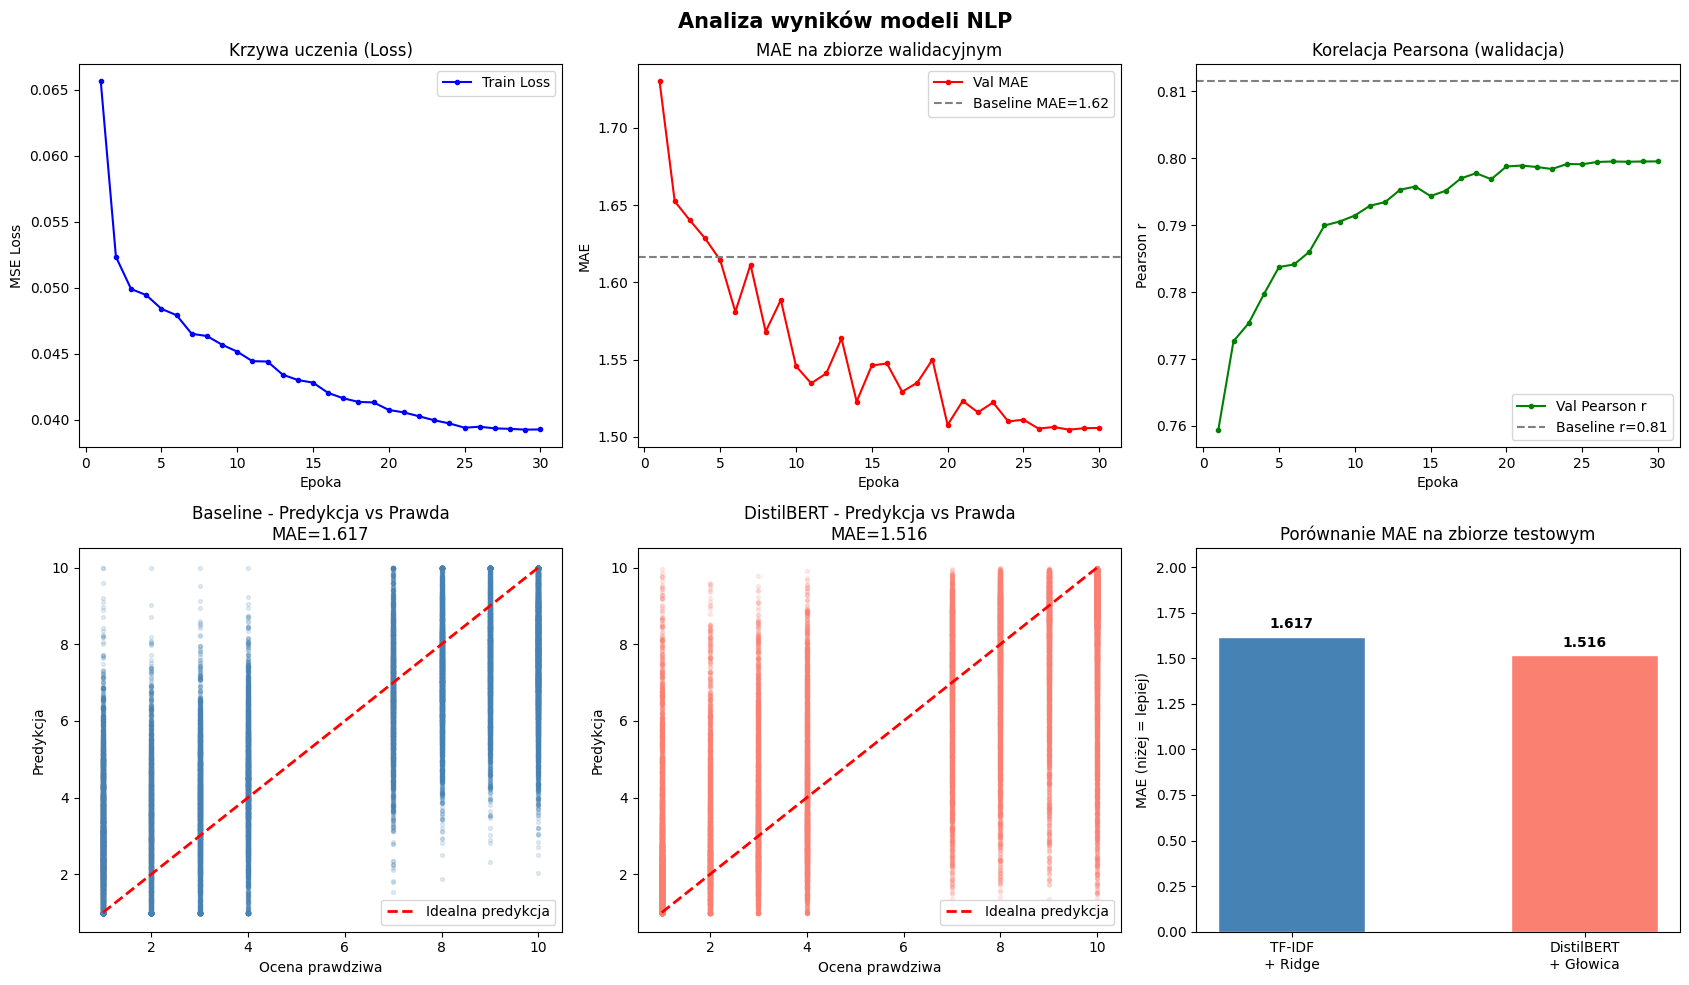

Wykres zapisany jako results_plots.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Analiza wyników modeli NLP", fontsize=15, fontweight="bold")

epochs_range = range(1, EPOCHS + 1)

# 1) Krzywa uczenia - Loss
axes[0, 0].plot(epochs_range, history["train_loss"], "b-o", ms=3, label="Train Loss")
axes[0, 0].set_xlabel("Epoka"); axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].set_title("Krzywa uczenia (Loss)")
axes[0, 0].legend()

# 2) Krzywa uczenia - MAE
axes[0, 1].plot(epochs_range, history["val_mae"], "r-o", ms=3, label="Val MAE")
axes[0, 1].axhline(base_mae, color="gray", linestyle="--", label=f"Baseline MAE={base_mae:.2f}")
axes[0, 1].set_xlabel("Epoka"); axes[0, 1].set_ylabel("MAE")
axes[0, 1].set_title("MAE na zbiorze walidacyjnym")
axes[0, 1].legend()

# 3) Krzywa uczenia - Pearson r
axes[0, 2].plot(epochs_range, history["val_r"], "g-o", ms=3, label="Val Pearson r")
axes[0, 2].axhline(base_r, color="gray", linestyle="--", label=f"Baseline r={base_r:.2f}")
axes[0, 2].set_xlabel("Epoka"); axes[0, 2].set_ylabel("Pearson r")
axes[0, 2].set_title("Korelacja Pearsona (walidacja)")
axes[0, 2].legend()

# 4) Predykcja vs Prawda - Baseline
axes[1, 0].scatter(y_test, baseline_preds, alpha=0.15, s=8, color="steelblue")
axes[1, 0].plot([1, 10], [1, 10], "r--", linewidth=2, label="Idealna predykcja")
axes[1, 0].set_xlabel("Ocena prawdziwa"); axes[1, 0].set_ylabel("Predykcja")
axes[1, 0].set_title(f"Baseline - Predykcja vs Prawda\nMAE={base_mae:.3f}")
axes[1, 0].legend(); axes[1, 0].set_xlim(0.5, 10.5); axes[1, 0].set_ylim(0.5, 10.5)

# 5) Predykcja vs Prawda - DistilBERT
reg_model.eval()
bert_preds_all = []
with torch.no_grad():
    for emb, _ in test_loader:
        bert_preds_all.extend(reg_model(emb.to(device)).cpu().numpy())
bert_preds_all = np.clip(bert_preds_all, 1, 10)

axes[1, 1].scatter(y_test, bert_preds_all, alpha=0.15, s=8, color="salmon")
axes[1, 1].plot([1, 10], [1, 10], "r--", linewidth=2, label="Idealna predykcja")
axes[1, 1].set_xlabel("Ocena prawdziwa"); axes[1, 1].set_ylabel("Predykcja")
axes[1, 1].set_title(f"DistilBERT - Predykcja vs Prawda\nMAE={bert_test_mae:.3f}")
axes[1, 1].legend(); axes[1, 1].set_xlim(0.5, 10.5); axes[1, 1].set_ylim(0.5, 10.5)

# 6) Porównanie słupkowe
models  = ["TF-IDF\n+ Ridge", "DistilBERT\n+ Głowica"]
maes    = [base_mae, bert_test_mae]
colors  = ["steelblue", "salmon"]
bars    = axes[1, 2].bar(models, maes, color=colors, edgecolor="white", width=0.5)
axes[1, 2].set_ylabel("MAE (niżej = lepiej)")
axes[1, 2].set_title("Porównanie MAE na zbiorze testowym")
axes[1, 2].set_ylim(0, max(maes) * 1.3)
for bar, mae in zip(bars, maes):
    axes[1, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                    f"{mae:.3f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("results_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany jako results_plots.png")


## 9. Analiza błędów

MAE według prawdziwej oceny:

        DistilBERT  Baseline
rating                      
1            1.504     1.840
2            1.364     1.589
3            1.344     1.397
4            1.502     1.251
7            1.489     1.160
8            1.410     1.265
9            1.448     1.624
10           1.796     2.118


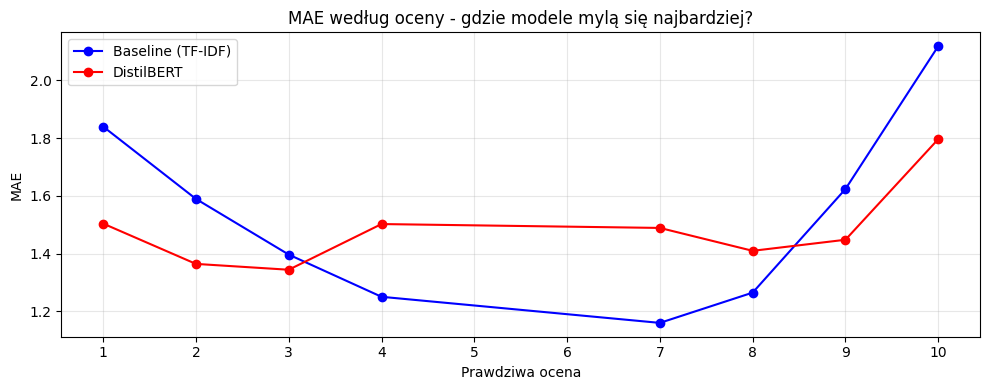

In [ ]:
df_results = df_test.copy()
df_results["pred_bert"]     = bert_preds_all
df_results["pred_baseline"] = baseline_preds
df_results["error_bert"]    = abs(df_results["rating"] - df_results["pred_bert"])
df_results["error_base"]    = abs(df_results["rating"] - df_results["pred_baseline"])

# MAE wg oceny
mae_by_rating = df_results.groupby("rating")[["error_bert", "error_base"]].mean()
print("MAE według prawdziwej oceny:\n")
print(mae_by_rating.rename(columns={"error_bert": "DistilBERT", "error_base": "Baseline"}).round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
x = mae_by_rating.index
ax.plot(x, mae_by_rating["error_base"], "b-o", label="Baseline (TF-IDF)")
ax.plot(x, mae_by_rating["error_bert"], "r-o", label="DistilBERT")
ax.set_xlabel("Prawdziwa ocena"); ax.set_ylabel("MAE")
ax.set_title("MAE według oceny - gdzie modele mylą się najbardziej?")
ax.set_xticks(range(1, 11)); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("error_by_rating.png", dpi=150)
plt.show()


In [ ]:
print("\nNajbardziej mylące recenzje (największy błąd DistilBERT):\n")
worst = df_results.nlargest(5, "error_bert")[["text", "rating", "pred_bert", "error_bert"]]
for _, row in worst.iterrows():
    print(f"  Prawdziwa: {row['rating']}/10  |  Predykcja: {row['pred_bert']:.1f}/10  |  Błąd: {row['error_bert']:.1f}")
    print(f"  {row['text'][:200]}...")
    print()



Najbardziej mylące recenzje (największy błąd DistilBERT):

  Prawdziwa: 10/10  |  Predykcja: 1.0/10  |  Błąd: 9.0
  OK. Who ever invented this film hates humanity and wants to see them all slit their throats. This "film" was absolute and utter filth. What the heck was up with the weird old bags eyes? Seriously, was...

  Prawdziwa: 10/10  |  Predykcja: 1.0/10  |  Błąd: 9.0
  Hey there Army Sgt. I'm sorry dude but being a SGT in the Army and being in the Army National Guard does not make you qualified to comment on a Marine movie. You are not a Marine and just because you ...

  Prawdziwa: 1/10  |  Predykcja: 10.0/10  |  Błąd: 9.0
  This movie was pure genius. John Waters is brilliant. It is hilarious and I am not sick of it even after seeing it about 20 times since I bought it a few months ago. The acting is great, although Rick...

  Prawdziwa: 1/10  |  Predykcja: 9.9/10  |  Błąd: 8.9
  This has to be one of, if not THE greatest Mob/Crime films of all time. Every thing about this mov

## 10. Demo - własne recenzje

Tutaj możesz wpisać dowolną recenzję po angielsku i sprawdzić, jaką ocenę przewidzi model.


In [ ]:
def predict_rating(text: str, verbose: bool = True) -> float:
    """Przewiduje ocenę (1–10) dla podanego tekstu recenzji."""
    # Ekstrakcja embeddingu
    bert_model_pred = DistilBertModel.from_pretrained(MODEL_NAME).to(device)
    bert_model_pred.eval()

    clean = clean_text(text)
    enc   = tokenizer(clean, max_length=MAX_LEN, truncation=True,
                      padding="max_length", return_tensors="pt")

    with torch.no_grad():
        out  = bert_model_pred(
            input_ids=enc["input_ids"].to(device),
            attention_mask=enc["attention_mask"].to(device),
        )
        cls_emb = out.last_hidden_state[:, 0, :]
        score   = reg_model(cls_emb).item()

    del bert_model_pred
    score = float(np.clip(score, 1, 10))

    if verbose:
        bar  = "█" * int(score) + "░" * (10 - int(score))
        print(f"  Ocena: {score:.1f}/10  [{bar}]")

    return score

# -- Wczytaj najlepszy model przed demo ----------------------------------------
reg_model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
reg_model.eval()

examples = [
    ("Doskonała",  "This film is an absolute masterpiece. Breathtaking cinematography, a deeply emotional story, and career-best performances from the entire cast. It left me speechless."),
    ("Przeciętna", "An average film. Some scenes are entertaining but the pacing is slow and the characters feel underdeveloped. Worth a watch on a lazy Sunday, nothing more."),
    ("Okropna",    "Complete garbage. The plot makes no sense, the acting is wooden, and the ending is infuriating. I walked out after 40 minutes. Do not waste your time or money."),
]

print("=" * 65)
print("  DEMO - PREDYKCJA OCENY RECENZJI")
print("=" * 65)
for label, review in examples:
    print(f"\n[{label}]")
    print(f"  \"{review[:100]}...\"")
    predict_rating(review)


  DEMO - PREDYKCJA OCENY RECENZJI

[Doskonała]
  "This film is an absolute masterpiece. Breathtaking cinematography, a deeply emotional story, and car..."


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4886.64it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ocena: 9.9/10  [█████████░]

[Przeciętna]
  "An average film. Some scenes are entertaining but the pacing is slow and the characters feel underde..."


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7115.26it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ocena: 3.7/10  [███░░░░░░░]

[Okropna]
  "Complete garbage. The plot makes no sense, the acting is wooden, and the ending is infuriating. I wa..."


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6716.80it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ocena: 1.0/10  [█░░░░░░░░░]


In [ ]:
# Miejsce na własną recenzję
my_review = """
The movie was decent.
"""

print("[Własna]")
print(f"  \"{my_review.strip()[:120]}...\"")
predict_rating(my_review)


[Własna]
  "The movie was decent...."


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6608.22it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Ocena: 7.3/10  [███████░░░]


7.284304618835449

## 11. Fine-tuning DistilBERT na GPU

In [ ]:
# -- Sprawdzenie GPU ------------------------------------------------------------
assert torch.cuda.is_available(), "GPU niedostępne, sprawdź instalację PyTorch+CUDA."
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
device = torch.device("cuda")

GPU: NVIDIA GeForce RTX 3060 Ti
VRAM: 8.6 GB


In [ ]:
# -- Konfiguracja fine-tuningu --------------------------------------------------
FT_EPOCHS   = 4
FT_LR       = 2e-5       # Niskie LR - nie "zapomniemy" wiedzy pre-treningu
FT_BATCH    = 32         # RTX 3060 Ti (8 GB VRAM): batch=32 przy MAX_LEN=256
FT_MAX_LEN  = 256
WARMUP_FRAC = 0.1        # 10% epoki na warmup LR

class FullReviewDataset(Dataset):
    """Dataset łączący tokenizację z etykietami - do pełnego fine-tuningu."""
    def __init__(self, texts, ratings, tokenizer, max_len):
        self.texts     = list(texts)
        self.ratings   = torch.tensor(list(ratings), dtype=torch.float32) / 10.0
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "rating":         self.ratings[idx],
        }


class FullDistilBertRegressor(nn.Module):
    """DistilBERT z głowicą regresji - wszystkie wagi są trenowalne."""
    def __init__(self, model_name=MODEL_NAME, dropout=0.2):
        super().__init__()
        self.bert      = DistilBertModel.from_pretrained(model_name)
        self.regressor = nn.Sequential(
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]           # [CLS] token
        return self.regressor(cls).squeeze(-1) * 10.0  # → [0, 10]


In [ ]:
# -- DataLoadery ---------------------------------------------------------------
ft_train_ds = FullReviewDataset(df_train["text"], df_train["rating"].values, tokenizer, FT_MAX_LEN)
ft_val_ds   = FullReviewDataset(df_val["text"],   df_val["rating"].values,   tokenizer, FT_MAX_LEN)
ft_test_ds  = FullReviewDataset(df_test["text"],  df_test["rating"].values,  tokenizer, FT_MAX_LEN)

ft_train_loader = DataLoader(ft_train_ds, batch_size=FT_BATCH, shuffle=True,  num_workers=0, pin_memory=True)
ft_val_loader   = DataLoader(ft_val_ds,   batch_size=FT_BATCH, shuffle=False, num_workers=0, pin_memory=True)
ft_test_loader  = DataLoader(ft_test_ds,  batch_size=FT_BATCH, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(ft_train_ds)} | Val: {len(ft_val_ds)} | Test: {len(ft_test_ds)}")
print(f"Batchy/epokę: {len(ft_train_loader)}")


Train: 22500 | Val: 2500 | Test: 25000
Batchy/epokę: 704


In [ ]:
from transformers import get_linear_schedule_with_warmup

ft_model     = FullDistilBertRegressor().to(device)
ft_optimizer = torch.optim.AdamW(ft_model.parameters(), lr=FT_LR, weight_decay=1e-2)
ft_criterion = nn.MSELoss()

total_steps  = len(ft_train_loader) * FT_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)
ft_scheduler = get_linear_schedule_with_warmup(
    ft_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

total_params = sum(p.numel() for p in ft_model.parameters())
print(f"Parametry łącznie: {total_params:,}  ({total_params/1e6:.1f}M)")
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6823.22it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parametry łącznie: 66,560,001  (66.6M)
Total steps: 2816 | Warmup steps: 281


In [ ]:
def eval_full_model(loader, model) -> tuple[float, float, float]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            rat  = batch["rating"].to(device) * 10.0  # de-normalizacja

            out = model(ids, mask)
            preds.extend(out.cpu().numpy())
            targets.extend(rat.cpu().numpy())

    p = np.clip(preds, 1, 10)
    t = np.array(targets)
    mae  = mean_absolute_error(t, p)
    rmse = float(np.sqrt(np.mean((t - p) ** 2)))
    r, _ = pearsonr(t, p)
    return mae, rmse, r

# -- Pętla treningowa ----------------------------------------------------------
ft_history   = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_r": []}
ft_best_mae  = float("inf")
FT_CKPT_PATH = "best_finetuned.pt"

print("=" * 60)
print("  FINE-TUNING DISTILBERT")
print("=" * 60)
print(f"  {'Epoka':>5}  {'Loss':>8}  {'Val MAE':>8}  {'Val RMSE':>9}  {'Val r':>7}")
print("  " + "-" * 50)

for epoch in range(1, FT_EPOCHS + 1):
    ft_model.train()
    epoch_loss = 0.0

    for batch in tqdm(ft_train_loader, desc=f"Epoka {epoch}/{FT_EPOCHS}", leave=False):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        rat  = batch["rating"].to(device)          # [0,1]

        ft_optimizer.zero_grad()
        pred = ft_model(ids, mask) / 10.0          # normalizacja do [0,1]
        loss = ft_criterion(pred, rat)
        loss.backward()
        nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)  # gradient clipping
        ft_optimizer.step()
        ft_scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(ft_train_loader)
    val_mae, val_rmse, val_r = eval_full_model(ft_val_loader, ft_model)

    ft_history["train_loss"].append(avg_loss)
    ft_history["val_mae"].append(val_mae)
    ft_history["val_rmse"].append(val_rmse)
    ft_history["val_r"].append(val_r)

    marker = ""
    if val_mae < ft_best_mae:
        ft_best_mae = val_mae
        torch.save(ft_model.state_dict(), FT_CKPT_PATH)
        marker = " ←"

    print(f"  {epoch:>5}  {avg_loss:>8.4f}  {val_mae:>8.3f}  {val_rmse:>9.3f}  {val_r:>7.3f}{marker}")

print(f"\n Najlepszy model fine-tuned zapisany (val_MAE={ft_best_mae:.3f})")


  FINE-TUNING DISTILBERT
  Epoka      Loss   Val MAE   Val RMSE    Val r
  --------------------------------------------------


      1    0.0496     1.264      1.788    0.860 ←


      2    0.0251     1.185      1.738    0.867 ←


      3    0.0170     1.158      1.729    0.870 ←


      4    0.0136     1.152      1.738    0.869 ←

 Najlepszy model fine-tuned zapisany (val_MAE=1.152)


In [ ]:
# -- Porównanie wszystkich modeli ----------------------------------------------
ft_model.load_state_dict(torch.load(FT_CKPT_PATH, map_location=device))
ft_test_mae, ft_test_rmse, ft_test_r = eval_full_model(ft_test_loader, ft_model)

print("=" * 65)
print("  PORÓWNANIE WSZYSTKICH MODELI - ZBIÓR TESTOWY")
print("=" * 65)
print(f"  {'Model':28} │ {'MAE':>6}  {'RMSE':>7}  {'Pearson r':>10}")
print("  " + "-" * 57)
print(f"  {'TF-IDF + Ridge (Baseline)':28} │ {base_mae:>6.3f}  {base_rmse:>7.3f}  {base_r:>10.3f}")
print(f"  {'DistilBERT + Głowica (CPU)':28} │ {bert_test_mae:>6.3f}  {bert_test_rmse:>7.3f}  {bert_test_r:>10.3f}")
print(f"  {'DistilBERT Fine-tuned (GPU)':28} │ {ft_test_mae:>6.3f}  {ft_test_rmse:>7.3f}  {ft_test_r:>10.3f}")

imp1 = (base_mae - bert_test_mae) / base_mae * 100
imp2 = (base_mae - ft_test_mae)   / base_mae * 100
imp3 = (bert_test_mae - ft_test_mae) / bert_test_mae * 100
print(f"\n  Feature extraction vs Baseline: {imp1:+.1f}% MAE")
print(f"  Fine-tuning vs Baseline:        {imp2:+.1f}% MAE")
print(f"  Fine-tuning vs Feature extract: {imp3:+.1f}% MAE")


  PORÓWNANIE WSZYSTKICH MODELI - ZBIÓR TESTOWY
  Model                        │    MAE     RMSE   Pearson r
  ---------------------------------------------------------
  TF-IDF + Ridge (Baseline)    │  1.617    2.059       0.812
  DistilBERT + Głowica (CPU)   │  1.516    2.107       0.798
  DistilBERT Fine-tuned (GPU)  │  1.143    1.720       0.873

  Feature extraction vs Baseline: +6.2% MAE
  Fine-tuning vs Baseline:        +29.3% MAE
  Fine-tuning vs Feature extract: +24.6% MAE


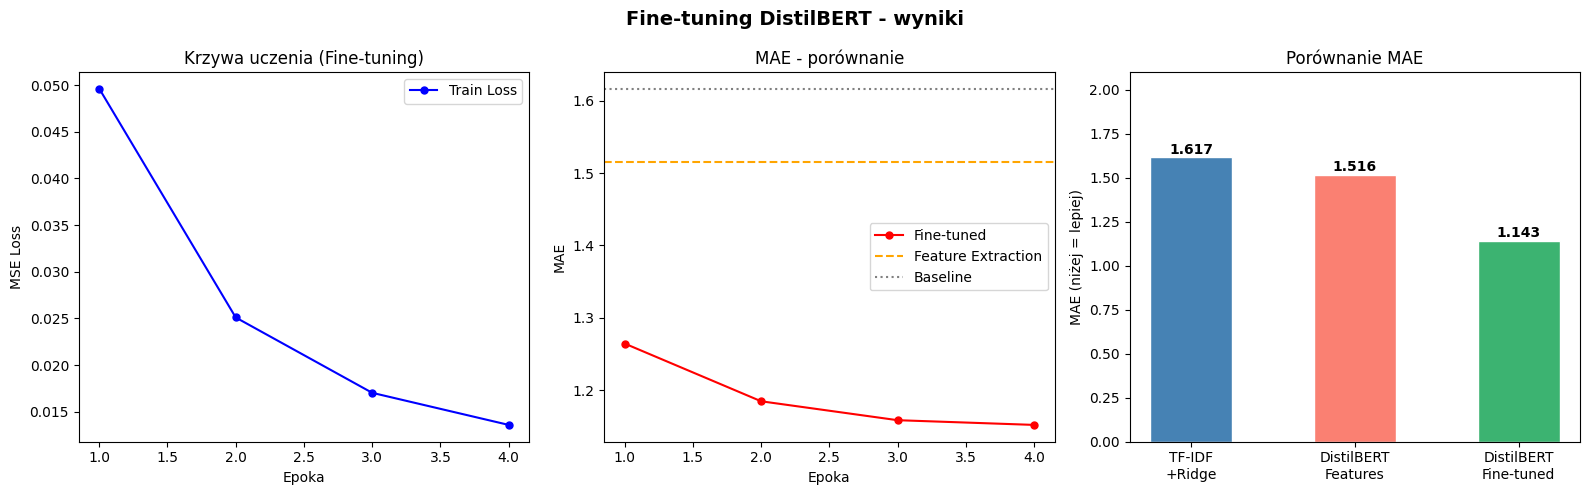

In [ ]:
# -- Wykresy porównawcze (fine-tuning) -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fine-tuning DistilBERT - wyniki", fontsize=14, fontweight="bold")

ep = range(1, FT_EPOCHS + 1)

axes[0].plot(ep, ft_history["train_loss"], "b-o", ms=5, label="Train Loss")
axes[0].set_title("Krzywa uczenia (Fine-tuning)"); axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("MSE Loss"); axes[0].legend()

axes[1].plot(ep, ft_history["val_mae"],  "r-o", ms=5, label="Fine-tuned")
axes[1].axhline(bert_test_mae, color="orange", linestyle="--", label="Feature Extraction")
axes[1].axhline(base_mae,      color="gray",   linestyle=":",  label="Baseline")
axes[1].set_title("MAE - porównanie"); axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("MAE"); axes[1].legend()

models_all = ["TF-IDF\n+Ridge", "DistilBERT\nFeatures", "DistilBERT\nFine-tuned"]
maes_all   = [base_mae, bert_test_mae, ft_test_mae]
colors_all = ["steelblue", "salmon", "mediumseagreen"]
bars = axes[2].bar(models_all, maes_all, color=colors_all, edgecolor="white", width=0.5)
axes[2].set_ylabel("MAE (niżej = lepiej)"); axes[2].set_title("Porównanie MAE")
axes[2].set_ylim(0, max(maes_all) * 1.3)
for bar, mae in zip(bars, maes_all):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{mae:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("finetune_results.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
class ReviewPredictor:
    """Wrapper do wygodnej predykcji. Wczytuje model raz."""
    def __init__(self, model, tokenizer, max_len=FT_MAX_LEN):
        self.model     = model
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.model.eval()

    def predict(self, text: str) -> float:
        clean = clean_text(text)
        enc   = self.tokenizer(
            clean, max_length=self.max_len, truncation=True,
            padding="max_length", return_tensors="pt"
        )
        with torch.no_grad():
            score = self.model(
                enc["input_ids"].to(device),
                enc["attention_mask"].to(device)
            ).item()
        return round(float(np.clip(score, 1, 10)), 1)

    def __call__(self, text: str, label: str = "") -> float:
        score = self.predict(text)
        bar   = "█" * round(score) + "░" * (10 - round(score))
        print(f"  {label+':':15} {score:>4}/10  [{bar}]")
        return score

predictor = ReviewPredictor(ft_model, tokenizer)

print("Demo - wpisz własną recenzję:")
print("=" * 55)

test_reviews = [
    ("Doskonała",    "This film is an absolute masterpiece. Breathtaking."),
    ("Przeciętna",   "An okay film. Nothing special but watchable."),
    ("Okropna",      "Terrible movie. Complete waste of time. Awful."),
    ("Twoja własna", "The movie was decent."),
]
for label, review in test_reviews:
    predictor(review, label)


Demo - wpisz własną recenzję:
  Doskonała:       9.7/10  [██████████]
  Przeciętna:      4.9/10  [█████░░░░░]
  Okropna:         1.1/10  [█░░░░░░░░░]
  Twoja własna:    7.3/10  [███████░░░]


## 12. Podsumowanie

### Wyniki

| Model | MAE | RMSE | Pearson r | Poprawa MAE vs Baseline |
|---|:---:|:---:|:---:|:---:|
| TF-IDF + Ridge Regression *(Baseline)* | 1.617 | 2.059 | 0.812 | - |
| DistilBERT - ekstrakcja cech *(CPU)* | 1.516 | 2.107 | 0.798 | +6.2% |
| DistilBERT - fine-tuning *(GPU)* | **1.143** | **1.720** | **0.873** | **+29.3%** |

*MAE - Mean Absolute Error (średni błąd bezwzględny, w punktach skali 1–10)*  
*RMSE - Root Mean Squared Error (pierwiastek błędu średniokwadratowego)*  
*Pearson r - współczynnik korelacji Pearsona między predykcją a prawdziwą oceną*  
*↓ niższa wartość = lepszy wynik, ↑ wyższa wartość = lepszy wynik*

**TF-IDF + Ridge (Baseline)**  
Prosty model klasyczny działający na częstości słów. Ignoruje kolejność i kontekst.  
Nie rozumie negacji ani sarkazmu (np. „not bad" może być rozpoznane jako „bad").

**DistilBERT + Głowica regresji**  
Pre-trenowany transformer rozumiejący kontekst słów. Token `[CLS]` agreguje  
informację z całej recenzji. Lepiej radzi sobie z idiomami i złożonymi zdaniami.

**DistilBERT - fine-tuning**  
W odróżnieniu od ekstrakcji cech, fine-tuning aktualizuje wszystkie 66M wag modelu,  
dostosowując go do konkretnego zadania. DistilBERT przestawia się z ogólnego rozumienia  języka na rozpoznawanie cech charakterystycznych dla ocen filmowych. Skutkuje to znacznie lepszą jakością embeddingów tokenu `[CLS]`, co przekłada się na najniższy błąd predykcji spośród wszystkich testowanych podejść.

**Ograniczenia**  
- Dataset nie zawiera ocen 5 i 6 - model może gorzej szacować średnich ocen
- DistilBERT obcina teksty do 256 tokenów (długie recenzje są skrócone)
- Pełny fine-tuning (GPU) jest bardzo wymagający obliczeniowo

### Wnioski

Najlepszy model (DistilBERT fine-tuned) osiągnął MAE = 1.151 punktu na skali 1–10 oraz korelację Pearsona r = 0.872 ze zbiorem testowym, co oznacza redukcję błędu o 29.3% względem modelu bazowego (TF-IDF + Ridge Regression).

Zaskakującym wynikiem jest gorszy Pearson r modelu opartego na ekstrakcji cech (0.798) w porównaniu do modelu bazowego (0.812), mimo lepszego MAE. Wynika to z faktu, że embeddingi DistilBERT bez fine-tuningu są optymalizowane pod zadanie Masked Language Modeling, a nie predykcję ocen - mała głowica regresji nie jest w stanie w pełni wykorzystać ich struktury.

Analiza błędów ujawniła obecność zaszumionych etykiet w datasecie - recenzje o jednoznacznie negatywnym wydźwięku posiadające ocenę 10/10 i odwrotnie. Tego rodzaju szum stanowi górne ograniczenie osiągalnej dokładności dla każdego modelu.